In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/data_clean.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [46]:
reference_date = df["InvoiceDate"].max()+ pd.Timedelta(days=1)

print("Derniere date de transaction :", df["InvoiceDate"].max())
print("Date de reference :", reference_date)

Derniere date de transaction : 2011-12-09 12:50:00
Date de reference : 2011-12-10 12:50:00


In [47]:
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [48]:
rfm[["Recency", "Frequency", "Monetary"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


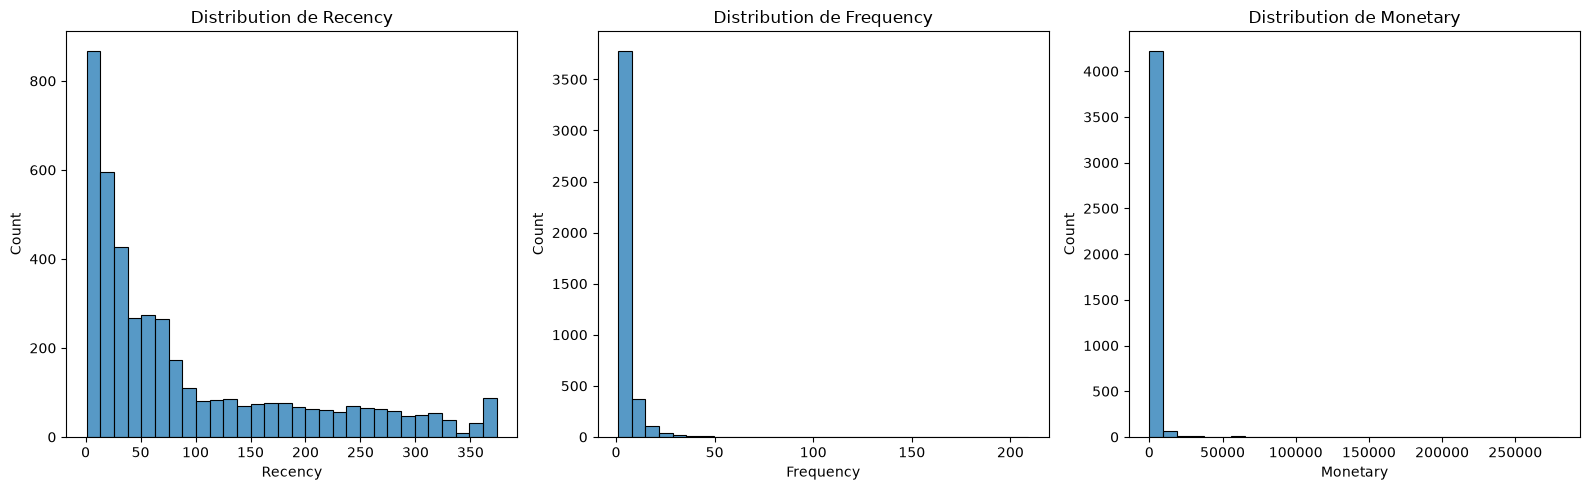

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(data=rfm, x="Recency", bins=30, ax=axes[0])
axes[0].set_title("Distribution de Recency")

sns.histplot(data=rfm, x="Frequency", bins=30, ax=axes[1])
axes[1].set_title("Distribution de Frequency")

sns.histplot(data=rfm, x="Monetary", bins=30, ax=axes[2])
axes[2].set_title("Distribution de Monetary")

plt.tight_layout()
plt.show()

In [53]:
rfm = rfm.reset_index()

rfm.to_csv("../data/rfm_data.csv", index=False)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
